<a href="https://www.kaggle.com/code/tuannm3812/birdclef-2026-eda?scriptVersionId=321294918" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/tuannm3812/birdclef-2026-eda?scriptVersionId=321290829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# BirdCLEF+ 2026 EDA

This notebook audits the training metadata, label distribution, soundscape annotations, and representative spectrograms before modeling. The goal is to turn dataset structure into concrete validation and modeling choices.


# 1. Setup And Inputs


## 1.1 Environment


In [1]:
from pathlib import Path
import json
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)


class CFG:
    seed = 42
    competition_name = "birdclef-2026"
    data_root = None
    artifact_dir = Path("/kaggle/working/artifacts")


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


def find_data_root() -> Path:
    candidates = [
        Path("/kaggle/input/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack"),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    input_root = Path("/kaggle/input")
    if input_root.exists():
        matches = list(input_root.glob("**/train.csv"))
        if matches:
            return matches[0].parent
    raise FileNotFoundError("Could not find train.csv. Attach the BirdCLEF 2026 dataset.")


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None


seed_everything(CFG.seed)
CFG.data_root = find_data_root()
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {CFG.data_root}")
print(f"Output directory: {CFG.artifact_dir}")

import ast
from collections import Counter

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

CFG.artifact_dir = CFG.artifact_dir / "eda"
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
VIRIDIS = sns.color_palette("viridis", n_colors=8)
VIRIDIS_CMAP = "viridis"


class CFG(CFG):
    sample_rate = 32000
    clip_seconds = 5
    n_mels = 128
    top_n = 30
    random_examples = 6


Data root: /kaggle/input/competitions/birdclef-2026
Output directory: /kaggle/working/artifacts


## 1.2 Metadata Tables


Load the competition tables, attach audio paths, parse secondary labels, and join taxonomy fields when available. The summary confirms the row counts, class count, soundscape label rows, and whether audio files are visible in the Kaggle input mount.


In [2]:
def parse_label_list(value) -> list[str]:
    if isinstance(value, list):
        return [str(x) for x in value]
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return [str(x) for x in parsed] if isinstance(parsed, list) else []


train = pd.read_csv(CFG.data_root / "train.csv")
taxonomy = read_optional_csv(CFG.data_root / "taxonomy.csv")
soundscape_labels = read_optional_csv(CFG.data_root / "train_soundscapes_labels.csv")
sample_submission = read_optional_csv(CFG.data_root / "sample_submission.csv")

train["filepath"] = train["filename"].map(lambda x: CFG.data_root / "train_audio" / x)
if "secondary_labels" in train.columns:
    train["secondary_labels"] = train["secondary_labels"].map(parse_label_list)
else:
    train["secondary_labels"] = [[] for _ in range(len(train))]

if taxonomy is not None and "primary_label" in taxonomy.columns:
    train = train.merge(taxonomy, on="primary_label", how="left", suffixes=("", "_taxonomy"))

summary = {
    "train_rows": len(train),
    "primary_classes": train["primary_label"].nunique(),
    "taxonomy_rows": 0 if taxonomy is None else len(taxonomy),
    "soundscape_label_rows": 0 if soundscape_labels is None else len(soundscape_labels),
    "sample_submission_rows": 0 if sample_submission is None else len(sample_submission),
    "audio_files_found": int(train["filepath"].map(Path.exists).sum()),
}
pd.Series(summary).to_csv(CFG.artifact_dir / "dataset_summary.csv", header=["value"])
display(pd.Series(summary).to_frame("value"))
display(train.head())


,value
train_rows,35549
primary_classes,206
taxonomy_rows,234
soundscape_label_rows,1478
sample_submission_rows,3
audio_files_found,35549


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,filepath,inat_taxon_id_taxonomy,scientific_name_taxonomy,common_name_taxonomy,class_name_taxonomy
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta


# 2. Data Integrity


## 2.1 Schema And Missingness


Check column types, missing values, unique counts, and missing audio paths. The baseline depends most on `filename`, `primary_label`, `secondary_labels`, and `duration`, so these fields get checked before any modeling assumptions are made.


In [3]:
def safe_nunique(series: pd.Series) -> int:
    values = series.map(make_hashable)
    return int(values.nunique(dropna=True))


def make_hashable(value):
    if isinstance(value, list):
        return tuple(make_hashable(item) for item in value)
    if isinstance(value, np.ndarray):
        return tuple(make_hashable(item) for item in value.tolist())
    if isinstance(value, dict):
        return tuple(sorted(((key, make_hashable(item)) for key, item in value.items()), key=repr))
    if isinstance(value, set):
        return tuple(sorted((make_hashable(item) for item in value), key=repr))
    return value


schema = pd.DataFrame(
    {
        "column": train.columns,
        "dtype": [str(train[col].dtype) for col in train.columns],
        "missing": [int(train[col].isna().sum()) for col in train.columns],
        "missing_pct": [float(train[col].isna().mean()) for col in train.columns],
        "unique": [safe_nunique(train[col]) for col in train.columns],
    }
)
schema.to_csv(CFG.artifact_dir / "train_schema_missingness.csv", index=False)
display(schema)

missing_files = train.loc[~train["filepath"].map(Path.exists), ["filename", "filepath"]]
missing_files.to_csv(CFG.artifact_dir / "missing_audio_files.csv", index=False)
print(f"Missing audio files: {len(missing_files):,}")


,column,dtype,missing,missing_pct,unique
0,primary_label,object,0,0.0,206
1,secondary_labels,object,0,0.0,1517
2,type,object,0,0.0,755
3,latitude,float64,0,0.0,15270
4,longitude,float64,0,0.0,15265
5,scientific_name,object,0,0.0,206
6,common_name,object,0,0.0,206
7,class_name,object,0,0.0,5
8,inat_taxon_id,int64,0,0.0,206
9,author,object,0,0.0,4017


Missing audio files: 0


## 2.2 Duplicate Records


Audit exact duplicate rows and key-level duplicates. Clean training clips reduce leakage risk; duplicated soundscape labels need deduplication before prevalence or overlap analysis.


In [4]:
duplicate_tables = {}
def duplicate_ready(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.apply(lambda col: col.map(make_hashable) if col.dtype == "object" else col)


for name, frame in {
    "train": train,
    "taxonomy": taxonomy,
    "soundscape_labels": soundscape_labels,
    "sample_submission": sample_submission,
}.items():
    if frame is None:
        continue
    frame_for_dupes = duplicate_ready(frame)
    dup_mask = frame_for_dupes.duplicated(keep=False)
    duplicate_tables[name] = int(dup_mask.sum())
    frame.loc[dup_mask].to_csv(CFG.artifact_dir / f"{name}_duplicate_rows.csv", index=False)

duplicate_summary = pd.Series(duplicate_tables, name="duplicate_rows").rename_axis("table").reset_index()
duplicate_summary.to_csv(CFG.artifact_dir / "duplicate_summary.csv", index=False)
display(duplicate_summary)

key_checks = []
for name, frame, candidates in [
    ("train", train, [["filename"], ["filepath"], ["primary_label", "filename"]]),
    ("taxonomy", taxonomy, [["primary_label"], ["scientific_name"]]),
    ("soundscape_labels", soundscape_labels, [["row_id"], ["filename"], ["filename", "primary_label"]]),
    ("sample_submission", sample_submission, [["row_id"]]),
]:
    if frame is None:
        continue
    frame_for_dupes = duplicate_ready(frame)
    for keys in candidates:
        if all(key in frame.columns for key in keys):
            key_dup_mask = frame_for_dupes.duplicated(subset=keys, keep=False)
            dup_count = int(key_dup_mask.sum())
            key_checks.append({"table": name, "keys": "+".join(keys), "duplicate_rows": dup_count})
            if dup_count:
                frame.loc[key_dup_mask].sort_values(keys).to_csv(
                    CFG.artifact_dir / f"{name}_{'_'.join(keys)}_duplicates.csv",
                    index=False,
                )

key_duplicate_summary = pd.DataFrame(key_checks)
key_duplicate_summary.to_csv(CFG.artifact_dir / "key_duplicate_summary.csv", index=False)
display(key_duplicate_summary)

if soundscape_labels is not None:
    soundscape_dedup = soundscape_labels.loc[~duplicate_ready(soundscape_labels).duplicated()].reset_index(drop=True)
    print(f"Soundscape labels before deduplication: {len(soundscape_labels):,}")
    print(f"Soundscape labels after deduplication: {len(soundscape_dedup):,}")
else:
    soundscape_dedup = None


,table,duplicate_rows
0,train,0
1,taxonomy,0
2,soundscape_labels,1478
3,sample_submission,0


,table,keys,duplicate_rows
0,train,filename,0
1,train,filepath,0
2,train,primary_label+filename,0
3,taxonomy,primary_label,0
4,taxonomy,scientific_name,0
5,soundscape_labels,filename,1478
6,soundscape_labels,filename+primary_label,1478
7,sample_submission,row_id,0


Soundscape labels before deduplication: 1,478
Soundscape labels after deduplication: 739


The clean-clip metadata is structurally safe, while `train_soundscapes_labels.csv` should be interpreted through a deduplicated view. This matters because repeated 5-second annotations can otherwise overstate label prevalence.


# 3. Training Labels


## 3.1 Primary Label Imbalance


Quantify the long tail before choosing samplers, augmentations, or validation metrics. The plots below show how quickly head classes accumulate training mass and how sparse the rare classes are.


Top 10 classes contain 13.9% of recordings.
Singleton classes: 4


,primary_label,recordings,share,cumulative_share,imbalance_ratio_vs_median
0,rubthr1,499,0.014037,0.014037,3.992
1,banana,498,0.014009,0.028046,3.984
2,fepowl,497,0.013981,0.042026,3.976
3,soulap1,497,0.013981,0.056007,3.976
4,houspa,496,0.013953,0.069960,3.968
5,coffal1,495,0.013924,0.083884,3.960
6,osprey,495,0.013924,0.097809,3.960
7,socfly1,494,0.013896,0.111705,3.952
8,compau,493,0.013868,0.125573,3.944
9,yeofly1,493,0.013868,0.139441,3.944


,primary_label,recordings,share,cumulative_share,imbalance_ratio_vs_median
176,1176823,12,0.000338,0.996006,0.096
177,1161364,11,0.000309,0.996315,0.088
178,24287,11,0.000309,0.996624,0.088
179,74113,10,0.000281,0.996906,0.080
180,22983,10,0.000281,0.997187,0.080
181,555145,9,0.000253,0.997440,0.072
182,22967,8,0.000225,0.997665,0.064
183,760266,7,0.000197,0.997862,0.056
184,67252,6,0.000169,0.998031,0.048
185,22985,6,0.000169,0.998200,0.048


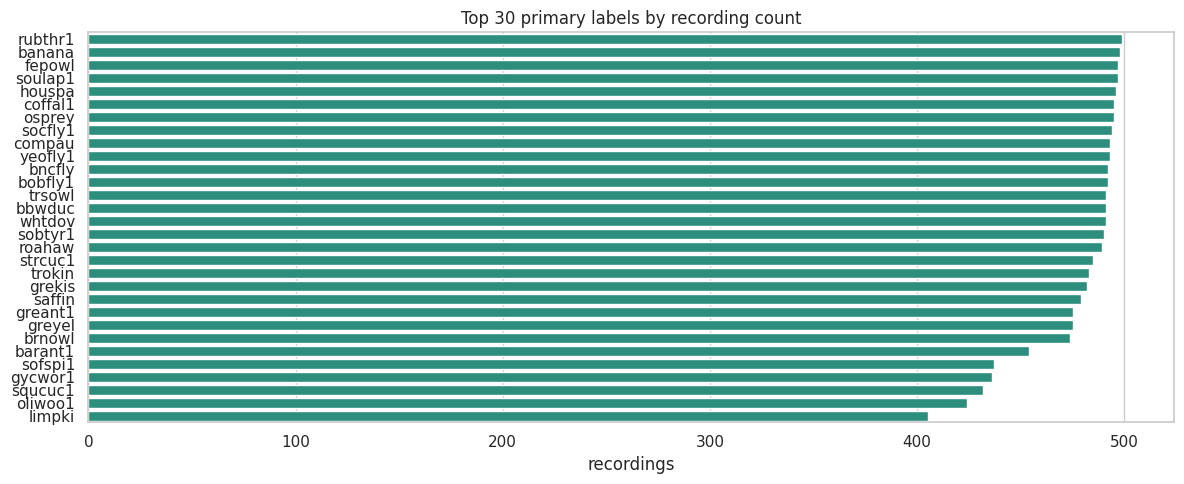

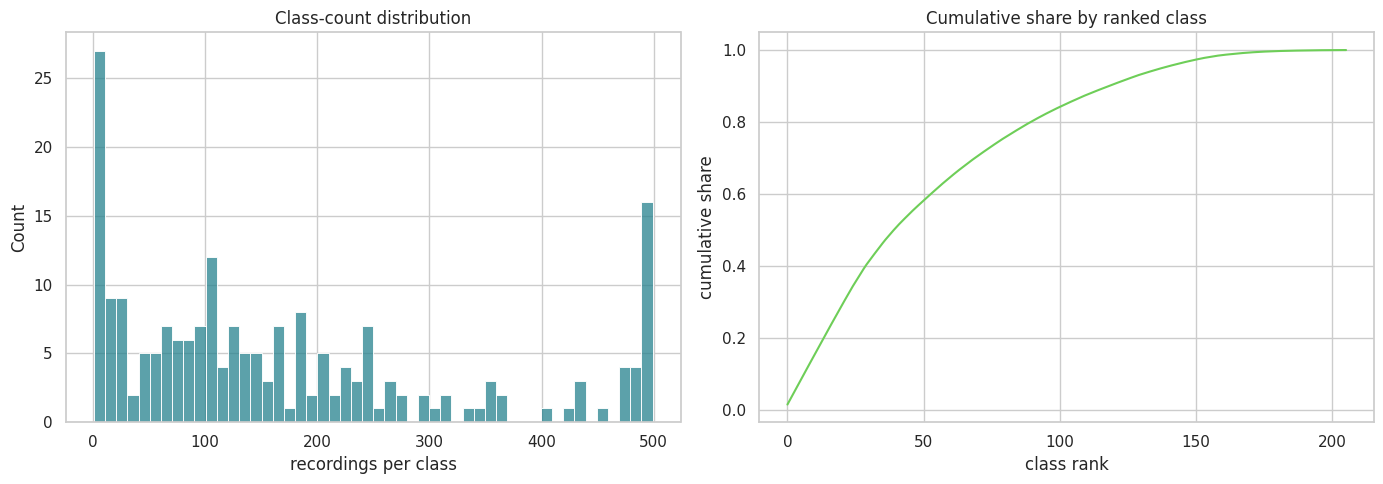

In [5]:
label_counts = (
    train["primary_label"]
    .value_counts()
    .rename_axis("primary_label")
    .reset_index(name="recordings")
)
label_counts["share"] = label_counts["recordings"] / label_counts["recordings"].sum()
label_counts["cumulative_share"] = label_counts["share"].cumsum()
label_counts["imbalance_ratio_vs_median"] = label_counts["recordings"] / label_counts["recordings"].median()
label_counts.to_csv(CFG.artifact_dir / "primary_label_counts.csv", index=False)

head_share = label_counts.head(10)["share"].sum()
tail_singletons = int((label_counts["recordings"] == 1).sum())
print(f"Top 10 classes contain {head_share:.1%} of recordings.")
print(f"Singleton classes: {tail_singletons:,}")
display(label_counts.head(CFG.top_n))
display(label_counts.tail(CFG.top_n))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=label_counts.head(CFG.top_n), x="recordings", y="primary_label", ax=ax, color=VIRIDIS[4])
ax.set_title(f"Top {CFG.top_n} primary labels by recording count")
ax.set_xlabel("recordings")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "top_primary_labels.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(label_counts["recordings"], bins=50, ax=axes[0], color=VIRIDIS[3])
axes[0].set_title("Class-count distribution")
axes[0].set_xlabel("recordings per class")
sns.lineplot(data=label_counts.reset_index(), x="index", y="cumulative_share", ax=axes[1], color=VIRIDIS[6])
axes[1].set_title("Cumulative share by ranked class")
axes[1].set_xlabel("class rank")
axes[1].set_ylabel("cumulative share")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "class_imbalance_diagnostics.png", dpi=160)
plt.show()


This run has 35,549 recordings across 206 primary labels. The median class has 125 recordings, the largest has 499, the smallest has 1, and the top 30 labels account for 40.3% of all recordings.


## 3.2 Few-Shot Buckets

Bucket classes by recording count to separate the rare tail from the broad middle and capped head. This gives a clearer target for class-aware sampling than a single imbalance ratio.


,bucket,classes,recordings,recording_share
0,1-5,18,52,0.001463
1,6-20,18,200,0.005626
2,21-100,47,2891,0.081324
3,>100,123,32406,0.911587


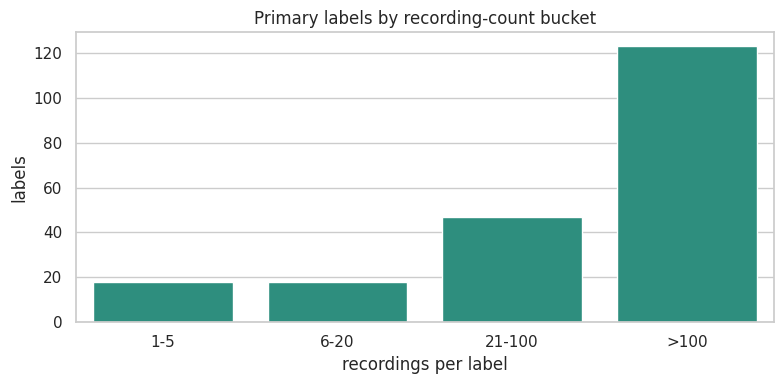

In [6]:
few_shot_bins = [0, 5, 20, 100, np.inf]
few_shot_labels = ["1-5", "6-20", "21-100", ">100"]
few_shot = label_counts.copy()
few_shot["bucket"] = pd.cut(
    few_shot["recordings"],
    bins=few_shot_bins,
    labels=few_shot_labels,
    include_lowest=True,
)
few_shot_summary = (
    few_shot.groupby("bucket", observed=False)
    .agg(classes=("primary_label", "count"), recordings=("recordings", "sum"))
    .reset_index()
)
few_shot_summary["recording_share"] = few_shot_summary["recordings"] / few_shot_summary["recordings"].sum()
few_shot_summary.to_csv(CFG.artifact_dir / "few_shot_buckets.csv", index=False)
display(few_shot_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=few_shot_summary, x="bucket", y="classes", ax=ax, color=VIRIDIS[4])
ax.set_title("Primary labels by recording-count bucket")
ax.set_xlabel("recordings per label")
ax.set_ylabel("labels")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "few_shot_buckets.png", dpi=160)
plt.show()


The rare tail is not a single group: singleton and near-singleton labels need different handling from labels with dozens of clips. Use this table to decide whether to oversample, augment, or reserve classes from validation folds.


## 3.3 Duration And Crop Design


A fixed 5-second training crop interacts with clip duration. Short clips are padded, while long clips can support random crops during training and multi-crop averaging during inference.


In [7]:
if "duration" in train.columns:
    duration_summary = train["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    duration_summary.to_csv(CFG.artifact_dir / "duration_summary.csv", header=["value"])
    display(duration_summary)

    duration_by_label = (
        train.groupby("primary_label")["duration"]
        .agg(recordings="count", median_duration="median", total_seconds="sum")
        .reset_index()
        .sort_values("total_seconds", ascending=False)
    )
    duration_by_label["estimated_5s_chunks"] = np.ceil(duration_by_label["total_seconds"] / CFG.clip_seconds).astype(int)
    duration_by_label.to_csv(CFG.artifact_dir / "duration_by_primary_label.csv", index=False)
    display(duration_by_label.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    clipped = train["duration"].clip(upper=train["duration"].quantile(0.99))
    sns.histplot(clipped, bins=60, ax=axes[0], color=VIRIDIS[3])
    axes[0].set_title("Audio duration distribution, clipped at p99")
    axes[0].set_xlabel("seconds")
    sns.scatterplot(
        data=duration_by_label,
        x="recordings",
        y="total_seconds",
        size="median_duration",
        sizes=(20, 180),
        alpha=0.7,
        ax=axes[1],
        color=VIRIDIS[5],
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title("Per-class recording count vs total audio")
    axes[1].set_xlabel("recordings, log scale")
    axes[1].set_ylabel("total seconds, log scale")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "duration_and_chunking.png", dpi=160)
    plt.show()
else:
    print("No duration column found in train.csv.")


No duration column found in train.csv.


## 3.4 Secondary Labels And Co-Occurrence


Secondary labels are noisy but useful context. They expose common co-occurrences that can later support soft targets, mixup labels, post-processing, or confusion analysis while keeping the first baseline single-label.


Rows with secondary labels: 4,372 (12.3%)


,secondary_label,mentions
0,grekis,624
1,whtdov,468
2,undtin1,315
3,yecpar,226
4,rufhor2,225
5,saffin,183
6,picpig2,172
7,trokin,171
8,soulap1,154
9,grasal3,151


,primary_label,secondary_labels,count
1212,grasal3,grekis,16
2612,saffin,grekis,16
402,bncfly,whtdov,15
2422,rufhor2,grekis,15
2949,socfly1,grekis,15
3232,strcuc1,grekis,15
1318,greant1,whtdov,14
3860,yebela1,trokin,14
419,bobfly1,grekis,14
1104,fusfly1,whtdov,13


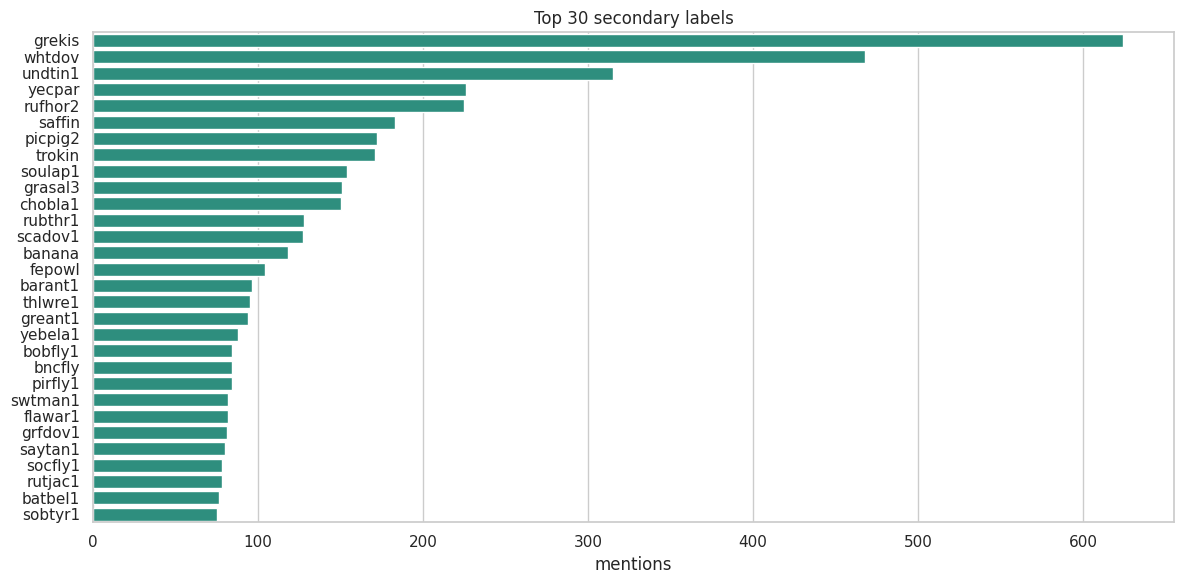

In [8]:
secondary = train[["filename", "primary_label", "secondary_labels"]].explode("secondary_labels")
secondary = secondary.dropna(subset=["secondary_labels"])
secondary_counts = (
    secondary["secondary_labels"]
    .value_counts()
    .rename_axis("secondary_label")
    .reset_index(name="mentions")
)
secondary_counts.to_csv(CFG.artifact_dir / "secondary_label_counts.csv", index=False)
rows_with_secondary = int((train["secondary_labels"].map(len) > 0).sum())
print(f"Rows with secondary labels: {rows_with_secondary:,} ({rows_with_secondary / len(train):.1%})")
display(secondary_counts.head(CFG.top_n))

cooccurrence = (
    secondary.groupby(["primary_label", "secondary_labels"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
cooccurrence.to_csv(CFG.artifact_dir / "primary_secondary_cooccurrence.csv", index=False)
display(cooccurrence.head(30))

if len(secondary_counts):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=secondary_counts.head(CFG.top_n), x="mentions", y="secondary_label", ax=ax, color=VIRIDIS[4])
    ax.set_title(f"Top {CFG.top_n} secondary labels")
    ax.set_xlabel("mentions")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "top_secondary_labels.png", dpi=160)
    plt.show()


Secondary labels contain 7,431 mentions across 161 labels. The most frequent labels, including `grekis`, `whtdov`, `undtin1`, `yecpar`, and `rufhor2`, are common enough to revisit in a soft-label experiment.


## 3.5 Taxonomy Coverage


Taxonomy metadata helps audit errors above the species-code level. Complete coverage also confirms that train labels can be mapped to broader biological groups for later diagnostics.


In [9]:
if taxonomy is not None:
    taxonomy.to_csv(CFG.artifact_dir / "taxonomy_copy.csv", index=False)
    display(taxonomy.head())
    taxonomy_cols = taxonomy.columns.tolist()
    print(taxonomy_cols)

    taxonomy_label_col = "primary_label" if "primary_label" in taxonomy.columns else None
    if taxonomy_label_col:
        train_labels = set(pd.read_csv(CFG.data_root / "train.csv")["primary_label"].unique())
        taxonomy_labels = set(taxonomy[taxonomy_label_col].dropna().astype(str).unique())
        coverage = {
            "train_labels": len(train_labels),
            "taxonomy_labels": len(taxonomy_labels),
            "train_labels_missing_from_taxonomy": len(train_labels - taxonomy_labels),
            "taxonomy_labels_not_in_train": len(taxonomy_labels - train_labels),
        }
        pd.Series(coverage).to_csv(CFG.artifact_dir / "taxonomy_coverage.csv", header=["value"])
        display(pd.Series(coverage).to_frame("value"))

    candidate_cols = [c for c in ["class_name", "order", "family", "genus", "species", "common_name", "scientific_name"] if c in train.columns]
    for col in candidate_cols[:4]:
        counts = train[col].value_counts(dropna=False).head(20).rename_axis(col).reset_index(name="recordings")
        display(counts)
else:
    print("No taxonomy.csv found.")


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


,value
train_labels,206
taxonomy_labels,234
train_labels_missing_from_taxonomy,0
taxonomy_labels_not_in_train,28


,class_name,recordings
0,Aves,34799
1,Amphibia,451
2,Insecta,199
3,Mammalia,99
4,Reptilia,1


,common_name,recordings
0,Rufous-bellied Thrush,499
1,Bananaquit,498
2,Ferruginous Pygmy Owl,497
3,Southern Lapwing,497
4,House Sparrow,496
5,Collared Forest-Falcon,495
6,Osprey,495
7,Social Flycatcher,494
8,Pauraque,493
9,Yellow-olive Flatbill,493


,scientific_name,recordings
0,Turdus rufiventris,499
1,Coereba flaveola,498
2,Glaucidium brasilianum,497
3,Vanellus chilensis,497
4,Passer domesticus,496
5,Micrastur semitorquatus,495
6,Pandion haliaetus,495
7,Myiozetetes similis,494
8,Nyctidromus albicollis,493
9,Tolmomyias sulphurescens,493


# 4. Metadata And Domain Shift


## 4.1 Quality, Source, And Geography


Ratings, collection source, author, license, and coordinates can become hidden confounders. This section checks whether validation should account for source concentration or geographic mismatch.


,rating,recordings
0,0.0,12849
1,0.5,22
2,1.0,147
3,1.5,120
4,2.0,598
5,2.5,518
6,3.0,2738
7,3.5,1509
8,4.0,8018
9,4.5,2185


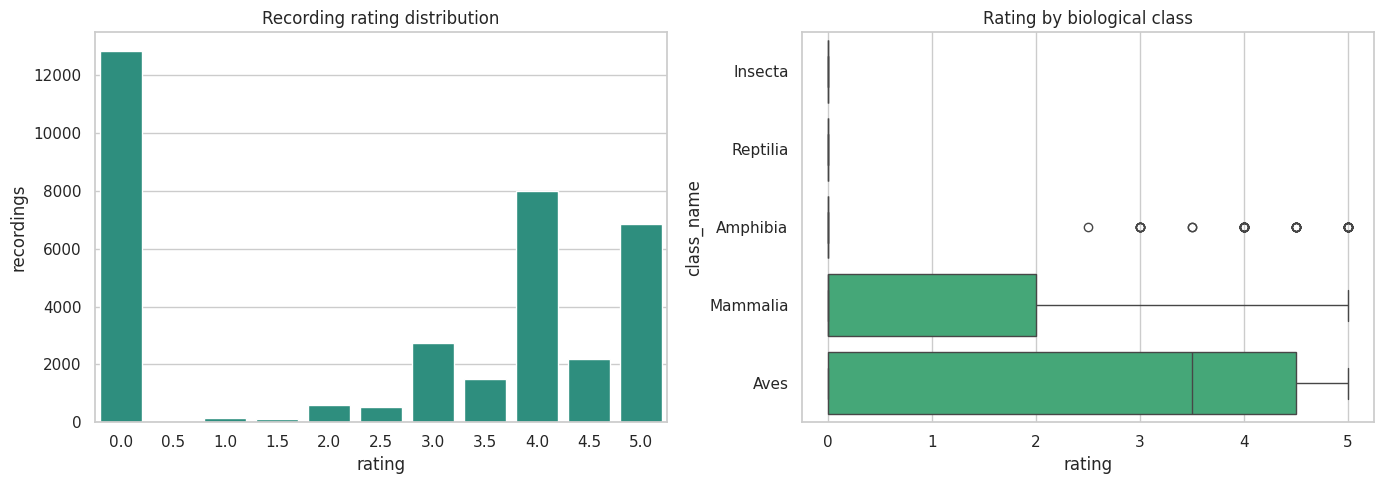

,value
records_with_coordinates,35549.000000
inside_pantanal_box,847.000000
inside_pantanal_share,0.023826
species_inside_pantanal,119.000000


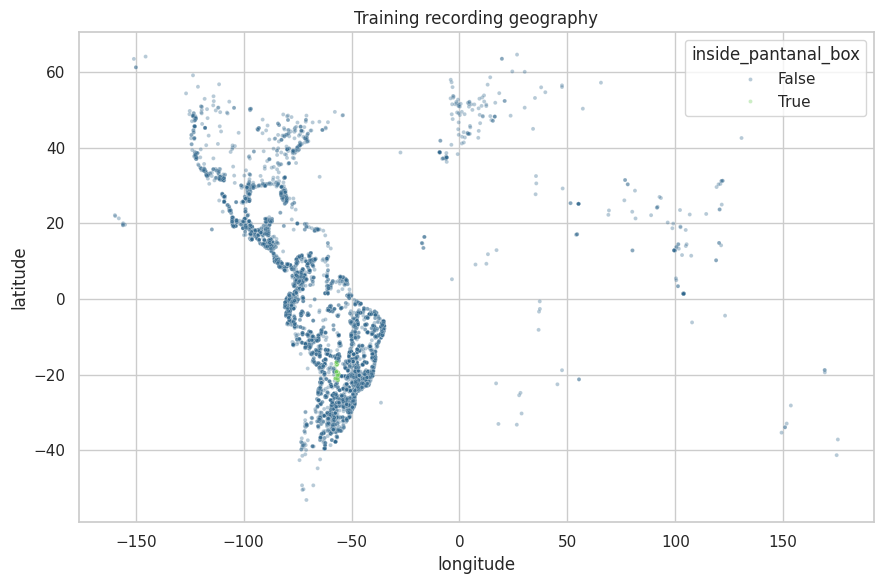

In [10]:
metadata_outputs = {}

if "rating" in train.columns:
    rating_counts = train["rating"].value_counts(dropna=False).sort_index().rename_axis("rating").reset_index(name="recordings")
    rating_counts.to_csv(CFG.artifact_dir / "rating_counts.csv", index=False)
    display(rating_counts)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=rating_counts, x="rating", y="recordings", ax=axes[0], color=VIRIDIS[4])
    axes[0].set_title("Recording rating distribution")
    if "class_name" in train.columns:
        quality_by_class = train.groupby("class_name")["rating"].agg(["count", "mean", "median"]).reset_index()
        quality_by_class.to_csv(CFG.artifact_dir / "quality_by_class.csv", index=False)
        sns.boxplot(data=train, x="rating", y="class_name", ax=axes[1], color=VIRIDIS[5])
        axes[1].set_title("Rating by biological class")
    else:
        axes[1].axis("off")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "metadata_quality_rating.png", dpi=160)
    plt.show()

for col in ["collection", "license", "type", "author"]:
    if col in train.columns:
        counts = train[col].value_counts(dropna=False).head(30).rename_axis(col).reset_index(name="recordings")
        counts.to_csv(CFG.artifact_dir / f"{col}_counts.csv", index=False)
        metadata_outputs[col] = len(counts)

if {"latitude", "longitude"}.issubset(train.columns):
    pantanal = {"lat_min": -21.6, "lat_max": -16.5, "lon_min": -57.6, "lon_max": -55.9}
    geo = train.dropna(subset=["latitude", "longitude"]).copy()
    geo["inside_pantanal_box"] = (
        geo["latitude"].between(pantanal["lat_min"], pantanal["lat_max"])
        & geo["longitude"].between(pantanal["lon_min"], pantanal["lon_max"])
    )
    geo_summary = pd.Series(
        {
            "records_with_coordinates": len(geo),
            "inside_pantanal_box": int(geo["inside_pantanal_box"].sum()),
            "inside_pantanal_share": float(geo["inside_pantanal_box"].mean()),
            "species_inside_pantanal": int(geo.loc[geo["inside_pantanal_box"], "primary_label"].nunique()),
        }
    )
    geo_summary.to_csv(CFG.artifact_dir / "geography_summary.csv", header=["value"])
    display(geo_summary.to_frame("value"))

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(
        data=geo.sample(min(len(geo), 12000), random_state=CFG.seed),
        x="longitude",
        y="latitude",
        hue="inside_pantanal_box",
        palette={False: VIRIDIS[2], True: VIRIDIS[6]},
        s=8,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title("Training recording geography")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "recording_geography.png", dpi=160)
    plt.show()


Rating, source, and geography are likely domain-shift variables. The EDA shows many rating-0 recordings, a strong XC/iNat split, and only 2.38% of clips inside the rough Pantanal box used here.


## 4.2 Soundscape Labels


Soundscapes are closer to the evaluation domain than clean clips: longer recordings, overlapping calls, background noise, and sparse 5-second labels. Deduplicated soundscape rows are used for overlap and hour diagnostics.


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


['filename', 'start', 'end', 'primary_label']


,value
rows,739
columns,4
label_like_columns,primary_label
time_like_columns,
file_like_columns,filename


,primary_label,rows
0,23158;24279;24321;517063;555146;65380;66971,27
1,24321;555146;65380;66971,18
2,517063,18
3,22973;517063;555146;65380,14
4,24279;24321;555146;65380;66971,13
5,23158;24279;24321;555146;65380;66971,13
6,516975,12
7,1491113;22967;22973;23158,12
8,22961;23158;24279;517063;555146;65380,12
9,23158;24321;25092;65380;66971,12


,value
count,739.000000
mean,4.224628
std,1.783966
min,1.000000
50%,4.000000
75%,5.000000
90%,7.000000
max,10.000000


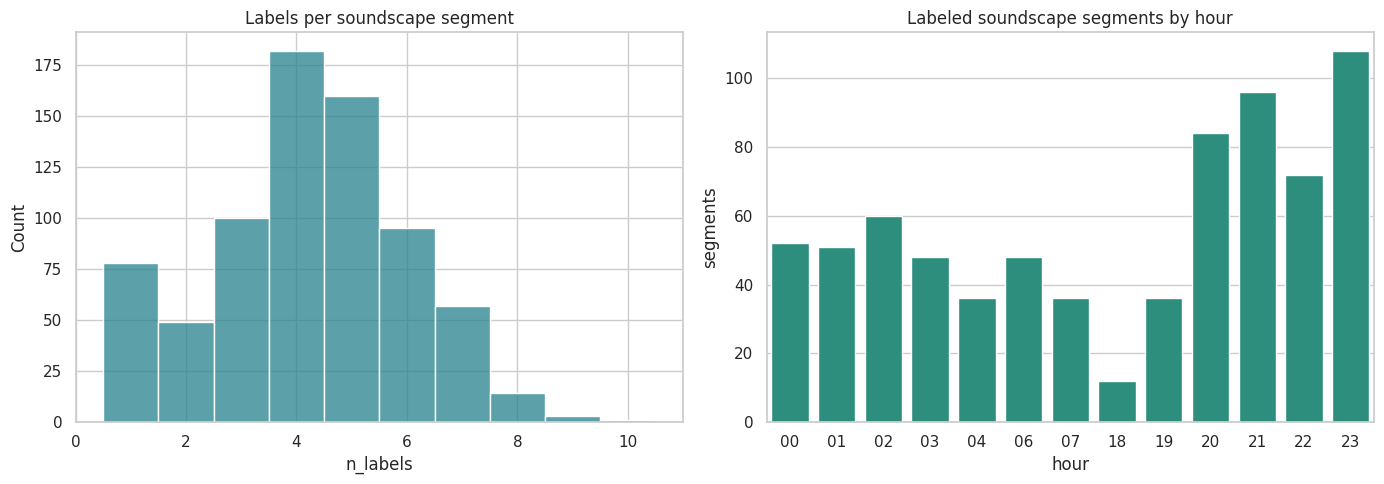

In [11]:
if soundscape_labels is None:
    print("No train_soundscapes_labels.csv found.")
else:
    soundscape_labels.to_csv(CFG.artifact_dir / "soundscape_labels_copy.csv", index=False)
    soundscape_analysis = soundscape_dedup if "soundscape_dedup" in globals() and soundscape_dedup is not None else soundscape_labels
    display(soundscape_analysis.head())
    print(soundscape_analysis.columns.tolist())

    label_like_cols = [c for c in soundscape_analysis.columns if "label" in c.lower() or "species" in c.lower() or "code" in c.lower()]
    time_like_cols = [c for c in soundscape_analysis.columns if "time" in c.lower() or "second" in c.lower()]
    file_like_cols = [c for c in soundscape_analysis.columns if "filename" in c.lower() or "soundscape" in c.lower() or "row_id" in c.lower()]

    soundscape_summary = {
        "rows": len(soundscape_analysis),
        "columns": len(soundscape_analysis.columns),
        "label_like_columns": ", ".join(label_like_cols),
        "time_like_columns": ", ".join(time_like_cols),
        "file_like_columns": ", ".join(file_like_cols),
    }
    pd.Series(soundscape_summary).to_csv(CFG.artifact_dir / "soundscape_summary.csv", header=["value"])
    display(pd.Series(soundscape_summary).to_frame("value"))

    if label_like_cols:
        col = label_like_cols[0]
        sc_counts = soundscape_analysis[col].value_counts().head(CFG.top_n).rename_axis(col).reset_index(name="rows")
        sc_counts.to_csv(CFG.artifact_dir / "soundscape_label_counts.csv", index=False)
        display(sc_counts)

    if {"filename", "primary_label"}.issubset(soundscape_analysis.columns):
        sc = soundscape_analysis.copy()
        sc["label_list"] = sc["primary_label"].astype(str).str.split(";")
        sc["n_labels"] = sc["label_list"].map(len)
        sc["site"] = sc["filename"].astype(str).str.extract(r"_(S\d+)_", expand=False)
        sc["hour"] = sc["filename"].astype(str).str.extract(r"_(\d{6})\.ogg$", expand=False).str[:2]
        overlap_summary = sc["n_labels"].describe(percentiles=[0.5, 0.75, 0.9]).to_frame("value")
        overlap_summary.to_csv(CFG.artifact_dir / "soundscape_overlap_summary.csv")
        display(overlap_summary)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.histplot(sc["n_labels"], discrete=True, ax=axes[0], color=VIRIDIS[3])
        axes[0].set_title("Labels per soundscape segment")
        if sc["hour"].notna().any():
            hour_counts = sc["hour"].value_counts().sort_index().rename_axis("hour").reset_index(name="segments")
            hour_counts.to_csv(CFG.artifact_dir / "soundscape_hour_counts.csv", index=False)
            sns.barplot(data=hour_counts, x="hour", y="segments", ax=axes[1], color=VIRIDIS[4])
            axes[1].set_title("Labeled soundscape segments by hour")
        else:
            axes[1].axis("off")
        fig.tight_layout()
        fig.savefig(CFG.artifact_dir / "soundscape_overlap_time.png", dpi=160)
        plt.show()


After deduplication there are 739 unique soundscape segments. A typical segment contains 4 labels, the 90th percentile contains 7, and evening/night hours dominate the labeled examples.


## 4.3 Soundscape Coverage Deep Dive

The labeled soundscape subset is small enough to inspect directly. These diagnostics check which species appear only in soundscapes, which sites and hours dominate, and whether labeled files are complete 12-window examples or partial annotations.


,value
soundscape_species,75
also_in_train_audio,47
soundscape_only_species,28
train_audio_only_species,159
unique_soundscape_segments,739
complete_12_window_files,59
partial_labeled_files,7


,soundscape_only_label
0,1491113
1,25073
2,47158son01
3,47158son02
4,47158son03
5,47158son04
6,47158son05
7,47158son06
8,47158son07
9,47158son08


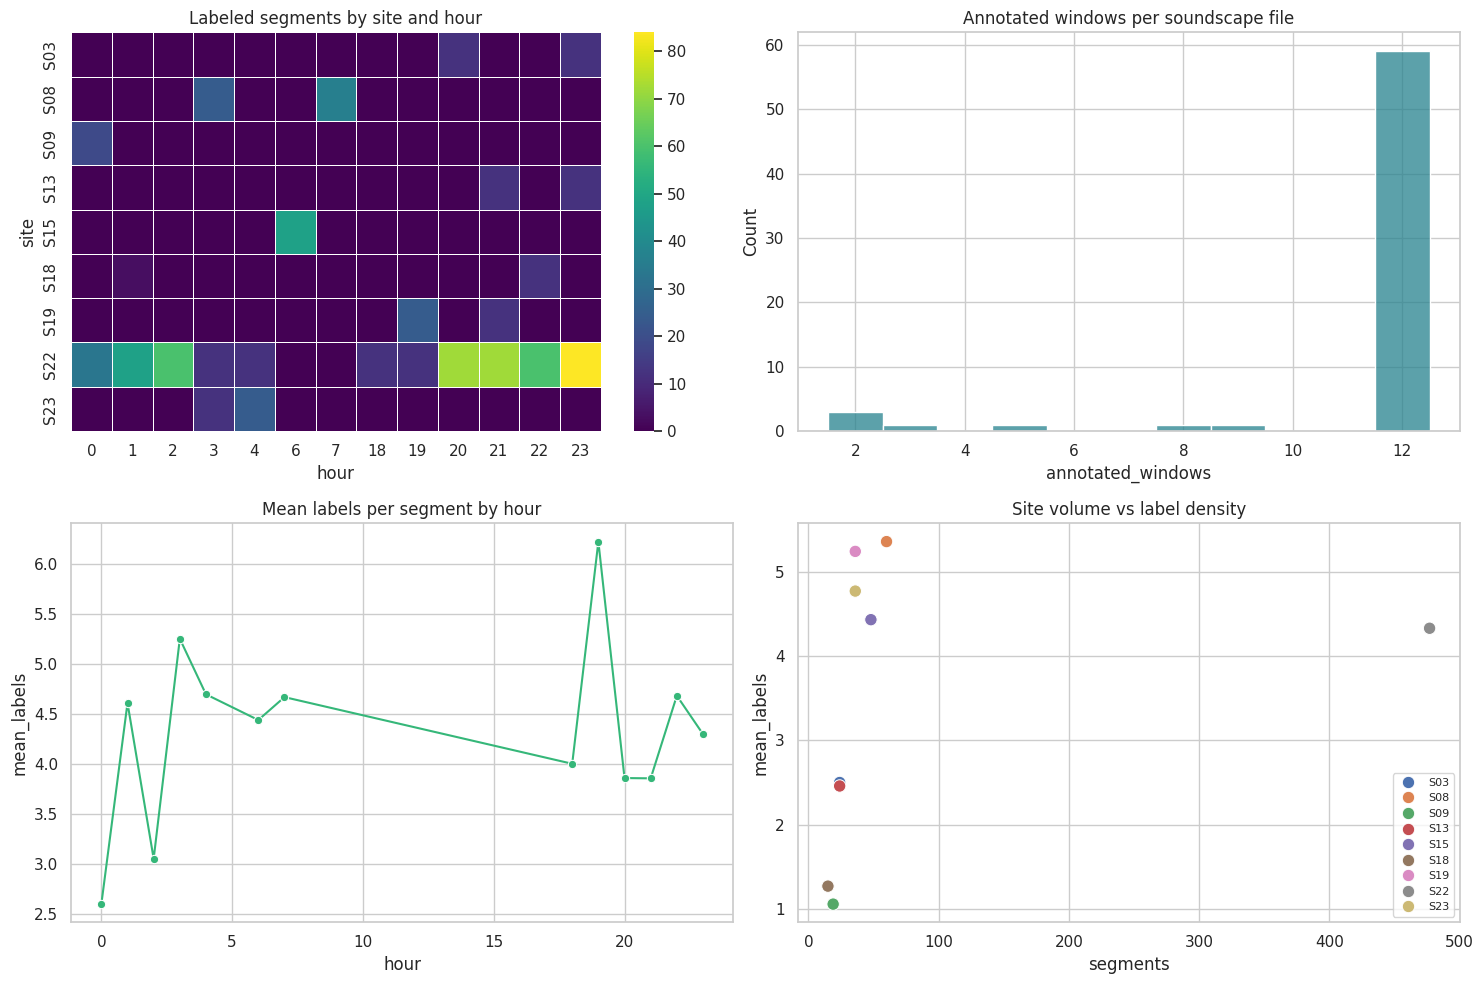

In [12]:
from itertools import combinations


def split_soundscape_labels(value) -> list[str]:
    if pd.isna(value):
        return []
    return [label.strip() for label in str(value).split(";") if label.strip()]


def parse_soundscape_filename(filename: str) -> pd.Series:
    stem = Path(str(filename)).stem
    parts = stem.split("_")
    site = next((part for part in parts if part.startswith("S") and part[1:].isdigit()), None)
    date_part = next((part for part in parts if len(part) == 8 and part.isdigit()), None)
    time_part = next((part for part in reversed(parts) if len(part) == 6 and part.isdigit()), None)
    return pd.Series(
        {
            "site": site,
            "month": int(date_part[4:6]) if date_part else np.nan,
            "hour": int(time_part[:2]) if time_part else np.nan,
        }
    )

if soundscape_labels is None:
    print("No soundscape labels available.")
else:
    sc_meta = soundscape_dedup.copy() if soundscape_dedup is not None else soundscape_labels.drop_duplicates().copy()
    sc_meta = pd.concat([sc_meta, sc_meta["filename"].apply(parse_soundscape_filename)], axis=1)
    sc_meta["label_list"] = sc_meta["primary_label"].map(split_soundscape_labels)
    sc_meta["n_labels"] = sc_meta["label_list"].map(len)

    sc_expanded = sc_meta.explode("label_list").rename(columns={"label_list": "label"})
    sc_expanded["label"] = sc_expanded["label"].astype(str)
    if taxonomy is not None:
        tax_cols = [col for col in ["primary_label", "common_name", "class_name"] if col in taxonomy.columns]
        sc_expanded = sc_expanded.merge(
            taxonomy[tax_cols].rename(columns={"primary_label": "label"}),
            on="label",
            how="left",
        )
        sc_expanded["display_name"] = sc_expanded.get("common_name", sc_expanded["label"]).fillna(sc_expanded["label"])
    else:
        sc_expanded["display_name"] = sc_expanded["label"]
        sc_expanded["class_name"] = "unknown"

    sc_species = set(sc_expanded["label"].dropna())
    train_species = set(train["primary_label"].astype(str))
    coverage_summary = pd.Series(
        {
            "soundscape_species": len(sc_species),
            "also_in_train_audio": len(sc_species & train_species),
            "soundscape_only_species": len(sc_species - train_species),
            "train_audio_only_species": len(train_species - sc_species),
            "unique_soundscape_segments": len(sc_meta),
            "complete_12_window_files": int((sc_meta.groupby("filename").size() == 12).sum()),
            "partial_labeled_files": int((sc_meta.groupby("filename").size() < 12).sum()),
        },
        name="value",
    ).to_frame()
    coverage_summary.to_csv(CFG.artifact_dir / "soundscape_coverage_deep_dive.csv")
    display(coverage_summary)

    soundscape_only = sorted(sc_species - train_species)
    if soundscape_only:
        display(pd.DataFrame({"soundscape_only_label": soundscape_only}).head(30))

    site_hour = sc_meta.pivot_table(index="site", columns="hour", values="filename", aggfunc="count", fill_value=0)
    file_windows = sc_meta.groupby("filename").size().rename("annotated_windows").reset_index()
    density_by_hour = sc_meta.groupby("hour")["n_labels"].agg(segments="count", mean_labels="mean").reset_index()
    density_by_site = sc_meta.groupby("site")["n_labels"].agg(segments="count", mean_labels="mean").reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    sns.heatmap(site_hour, cmap=VIRIDIS_CMAP, linewidths=0.4, ax=axes[0, 0])
    axes[0, 0].set_title("Labeled segments by site and hour")
    sns.histplot(file_windows["annotated_windows"], discrete=True, ax=axes[0, 1], color=VIRIDIS[3])
    axes[0, 1].set_title("Annotated windows per soundscape file")
    sns.lineplot(data=density_by_hour, x="hour", y="mean_labels", marker="o", ax=axes[1, 0], color=VIRIDIS[5])
    axes[1, 0].set_title("Mean labels per segment by hour")
    sns.scatterplot(data=density_by_site, x="segments", y="mean_labels", hue="site", s=80, ax=axes[1, 1])
    axes[1, 1].set_title("Site volume vs label density")
    axes[1, 1].legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "soundscape_site_hour_density.png", dpi=160)
    plt.show()


Coverage can be asymmetric: some labels may appear in soundscape annotations without clean `train_audio` examples, and some clean-label classes never appear in the labeled soundscapes. Site/hour concentration and partial files should shape validation, priors, and any calibration set built from soundscape labels.


## 4.4 Soundscape Activity And Co-Occurrence

Explode the multi-label soundscape rows to inspect class-level timing and repeated species pairs. This helps separate true multi-species chorus structure from ordinary class imbalance.


,label_a,label_b,segments
18,555146,65380,191
9,517063,65380,188
8,24321,65380,158
27,24279,65380,151
6,23158,65380,150
25,65380,66971,141
11,22973,517063,138
39,22967,22973,126
26,24279,555146,119
17,517063,555146,117


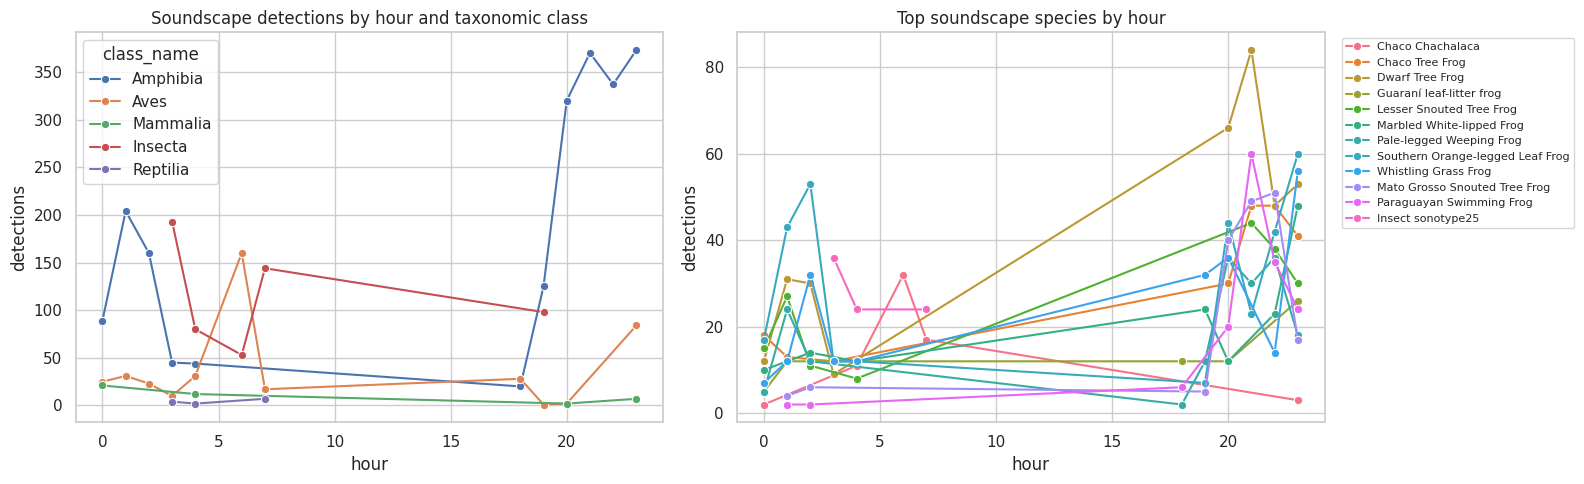

In [13]:
if soundscape_labels is None:
    print("No soundscape labels available.")
elif "sc_expanded" not in globals():
    print("Run the soundscape coverage cell first.")
else:
    class_hour = (
        sc_expanded.dropna(subset=["hour"])
        .groupby(["hour", "class_name"])
        .size()
        .reset_index(name="detections")
    )
    top_species = sc_expanded["display_name"].value_counts().head(12).index
    top_species_hour = (
        sc_expanded[sc_expanded["display_name"].isin(top_species)]
        .groupby(["hour", "display_name"])
        .size()
        .reset_index(name="detections")
    )

    pair_counts = Counter()
    for labels in sc_meta["label_list"]:
        for a, b in combinations(sorted(set(labels)), 2):
            pair_counts[(a, b)] += 1
    pair_df = pd.DataFrame(
        [(a, b, count) for (a, b), count in pair_counts.items()],
        columns=["label_a", "label_b", "segments"],
    ).sort_values("segments", ascending=False)
    pair_df.to_csv(CFG.artifact_dir / "soundscape_label_pair_counts.csv", index=False)
    display(pair_df.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=class_hour, x="hour", y="detections", hue="class_name", marker="o", ax=axes[0])
    axes[0].set_title("Soundscape detections by hour and taxonomic class")
    if len(top_species_hour):
        sns.lineplot(data=top_species_hour, x="hour", y="detections", hue="display_name", marker="o", ax=axes[1])
        axes[1].set_title("Top soundscape species by hour")
        axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    else:
        axes[1].axis("off")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "soundscape_activity_cooccurrence.png", dpi=160)
    plt.show()


If the leading pairs are concentrated within one taxonomic group or time window, post-processing should consider hour-conditioned thresholds or logit offsets instead of expecting the backbone to learn every temporal prior from audio alone.


## 4.5 Representative Spectrograms


Representative mel-spectrograms provide an acoustic sanity check: sparse calls, low-frequency background energy, repeated phrases, and frequency-specific vocal bands all affect crop and augmentation choices.


,filename,primary_label
0,23176/XC929082.ogg,23176
1,22973/XC892927.ogg,22973
2,yebela1/iNat1696413.ogg,yebela1
3,fabwre1/XC2199.ogg,fabwre1
4,camfli1/XC685648.ogg,camfli1
5,gretho2/XC589406.ogg,gretho2


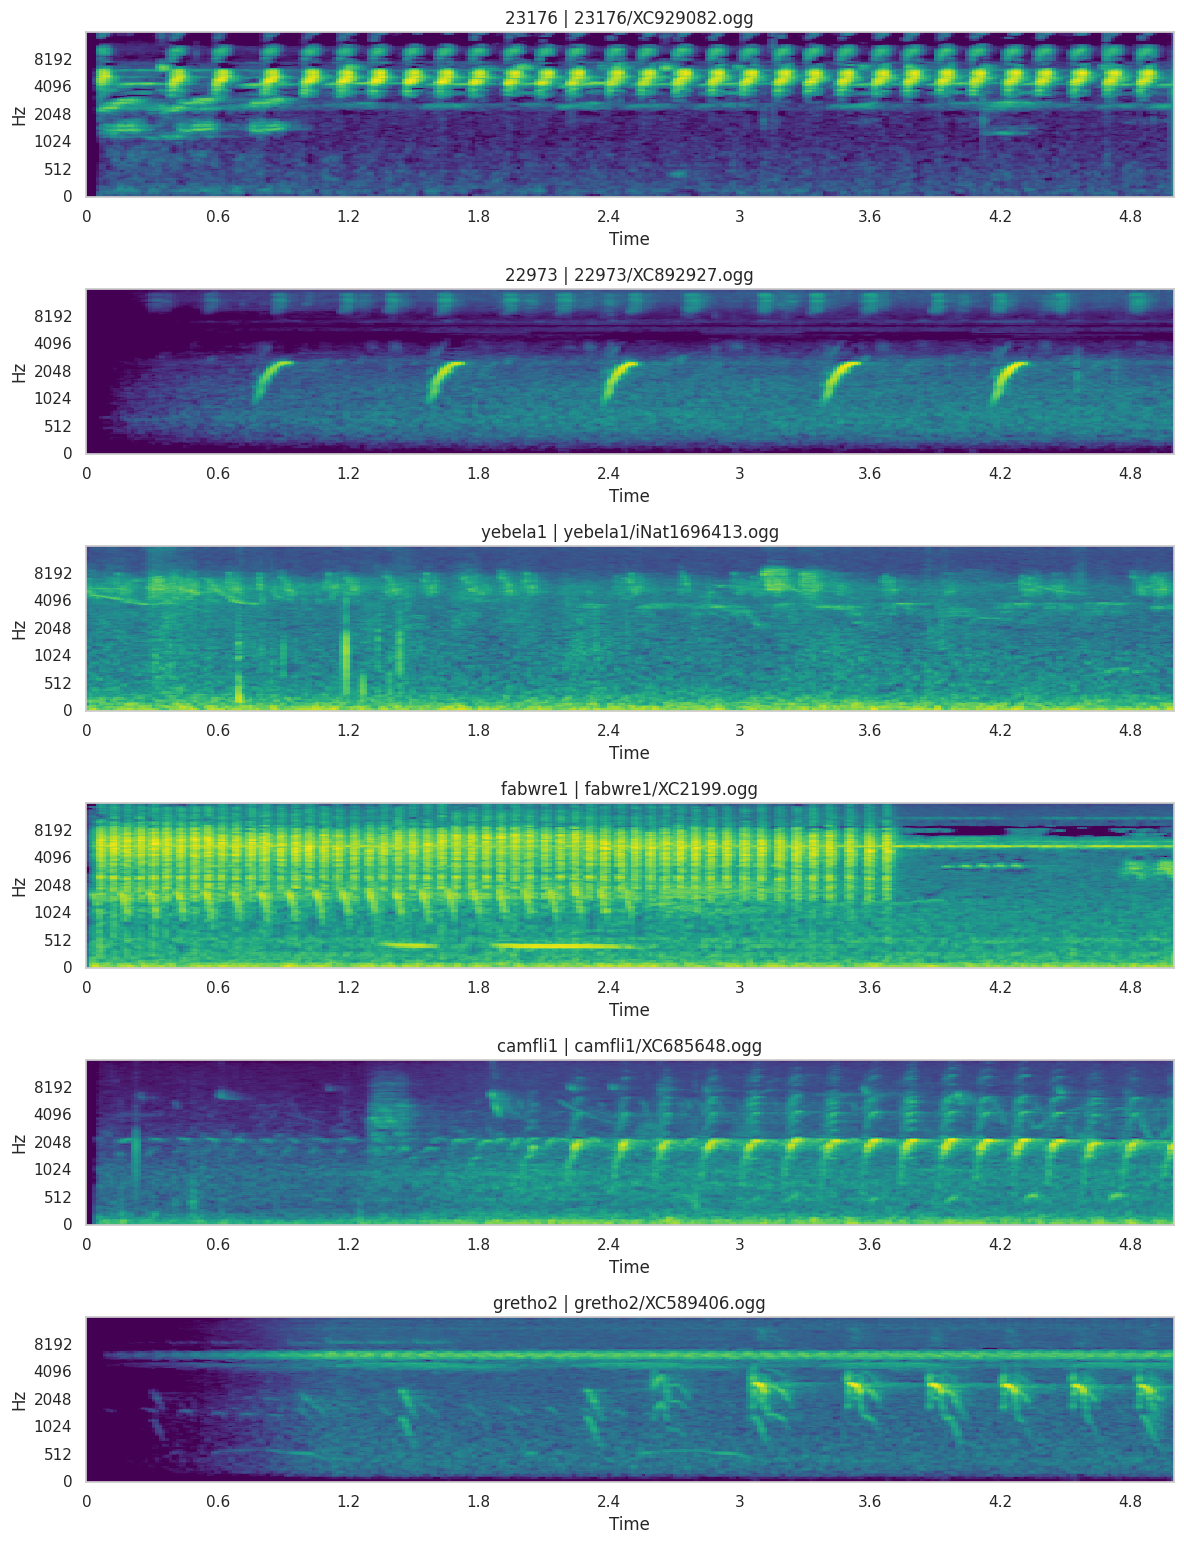

Audio preview: 23176 | 23176/XC929082.ogg


In [14]:
def load_clip(path: Path, seconds: float = 5.0) -> np.ndarray:
    y, _ = librosa.load(path, sr=CFG.sample_rate, mono=True, duration=seconds)
    target_len = int(CFG.sample_rate * seconds)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len].astype(np.float32)


available = train[train["filepath"].map(Path.exists)].copy()
if len(available) == 0:
    print("No local audio files available for previews.")
else:
    example_df = (
        available.groupby("primary_label", group_keys=False)
        .apply(lambda x: x.sample(1, random_state=CFG.seed))
        .sample(min(CFG.random_examples, available["primary_label"].nunique()), random_state=CFG.seed)
        .reset_index(drop=True)
    )
    example_df[["filename", "primary_label"]].to_csv(CFG.artifact_dir / "audio_examples.csv", index=False)
    display(example_df[["filename", "primary_label"]])

    fig, axes = plt.subplots(len(example_df), 1, figsize=(12, 2.6 * len(example_df)))
    axes = np.atleast_1d(axes)
    for ax, (_, row) in zip(axes, example_df.iterrows()):
        y = load_clip(row["filepath"], CFG.clip_seconds)
        mel = librosa.feature.melspectrogram(y=y, sr=CFG.sample_rate, n_mels=CFG.n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=CFG.sample_rate, x_axis="time", y_axis="mel", cmap=VIRIDIS_CMAP, ax=ax)
        ax.set_title(f"{row['primary_label']} | {row['filename']}")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "representative_mels.png", dpi=160)
    plt.show()

    first = example_df.iloc[0]
    print(f"Audio preview: {first['primary_label']} | {first['filename']}")
    display(Audio(load_clip(first["filepath"], CFG.clip_seconds), rate=CFG.sample_rate))


# 5. Modeling Implications

## 5.1 Modeling Guidance

- **Validation and sampling.** Class imbalance is the first constraint to solve. The top 30 labels account for 40.3% of recordings, while a small rare tail has very limited examples. Track per-class metrics, use class-aware sampling where appropriate, and treat aggregate validation accuracy as incomplete.
- **Crop and inference design.** A 5-second crop is a reasonable baseline, but clip durations vary. Long clips should support random training crops and multi-crop inference; sparse calls need crop strategies that reduce the chance of missing vocal activity.
- **Secondary labels.** Keep the first EfficientNet baseline single-label, then evaluate soft targets, mixup labels, co-occurrence priors, and post-hoc confusion analysis once the baseline is stable.
- **Soundscape calibration.** Soundscape labels are closer to the hidden-test domain than clean clips, but they are not a uniform validation set. Deduplicate them first, then account for soundscape-only species, site/hour concentration, partial files, and repeated co-occurrence structure before fitting thresholds or priors.
- **Model roadmap.** EfficientNet-B0 remains the dependable submission baseline because it is fast and pure PyTorch. Perch v2 provides stronger frozen representations and is best used as an offline feature source or teacher unless hidden-test inference is proven safe.


## 5.2 Save EDA Outputs

Save the generated EDA tables and figures as a compact Kaggle output bundle.


In [15]:
import zipfile
from IPython.display import FileLink

zip_path = Path("/kaggle/working/birdclef_eda_outputs.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(CFG.artifact_dir.rglob("*")):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(CFG.artifact_dir.parent))

print(f"Wrote {zip_path} ({zip_path.stat().st_size / 1024 / 1024:.2f} MB)")
display(FileLink(zip_path))


Wrote /kaggle/working/birdclef_eda_outputs.zip (1.76 MB)


/kaggle/working/birdclef_eda_outputs.zip